<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 7.2.1: Bagging

INSTRUCTIONS:

- Read the guides and hints then create the necessary analysis and code to find an answer and conclusion for the scenario below.
- The baseline results (minimum) are:
    - **Accuracy** = 0.9667
    - **ROC AUC**  = 0.9614
- Try to achieve better results!

# Foreword
It is common that companies and professionals start with the data immediately available. Although this approach works, ideally the first step is to identify the problem or question and only then identify and obtain the set of data that can help to solve or answer the problem.

Also, given the current abundance of data, processing power and some particular machine learning methods, there could be a temptation to use ALL the data available. **Quality** is _**better**_ than **Quantity**!

Part of calling this discipline **Data Science** is that it is supposed to follow a process and not reach conclusions without support from evidence.

Moreover, it is a creative, exploratory, laborious and iterative process. It is part of the process to repeat, review and change when finding a dead-end.

## Scenario: Predicting Breast Cancer
The dataset you are going to be using for this laboratory is popularly known as the **Wisconsin Breast Cancer** dataset (`breast-cancer-wisconsin-data-old.csv`). The task related to it is Classification.

The dataset contains a total number of _10_ features labelled in either **benign** or **malignant** classes. The features have _699_ instances out of which _16_ feature values are missing. The dataset only contains numeric values.

# Step 1: Define the problem or question
Identify the subject matter and the given or obvious questions that would be relevant in the field.

## Potential Questions
List the given or obvious questions.

Can we predict whether a tumor is benign or malignant based on given numeric features?

Which features contribute most significantly to the classification?

Are there patterns in the feature values that correlate with the type of tumor?

# Step 2: Find the Data
### Wisconsin Breast Cancer DataSet
- **Citation Request**

    This breast cancer databases was obtained from the **University of Wisconsin Hospitals**, **Madison** from **Dr. William H. Wolberg**. If you publish results when using this database, then please include this information in your acknowledgements.

- **Title**

    Wisconsin Breast Cancer Database (January 8, 1991)

- **Sources**
    - **Creator**
            Dr. William H. Wolberg (physician)
            University of Wisconsin Hospitals
            Madison, Wisconsin
            USA
    - **Donor**
            Olvi Mangasarian (mangasarian@cs.wisc.edu)
            Received by David W. Aha (aha@cs.jhu.edu)
    - **Date**
            15 July 1992
        
### UCI - Machine Learning Repository
- Center for Machine Learning and Intelligent Systems

The [**UCI Machine Learning Repository**](http://archive.ics.uci.edu/about) is a collection of databases, domain theories, and data generators that are used by the machine learning community for the empirical analysis of machine learning algorithms.

# Step 3: Read the Data
- Read the data (breast-cancer-wisconsin-data-old.csv)
- Perform some basic structural cleaning to facilitate the work

In [39]:
from google.colab import files
uploaded = files.upload()

Saving breast-cancer-wisconsin-data-old.csv to breast-cancer-wisconsin-data-old (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
breast_cancer = 'breast-cancer-wisconsin-data-old.csv'
df=pd.read_csv(breast_cancer)

# Step 4: Explore and Clean the Data
- Perform some initial simple **EDA** (Exploratory Data Analysis)
- Check for
    - **Number of features**
    - **Data types**
    - **Domains, Intervals**
    - **Outliers** (are they valid or spurious data [read or measure errors])
    - **Null** (values not present or coded [as zero of empty strings])
    - **Missing Values** (coded [as zero of empty strings] or values not present)
    - **Coded content** (classes identified by numbers or codes to represent absence of data)

In [ ]:
df.tail()

,Sample_number,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4
698,897471,4,8,8,5,4,5,10,4,1,4


In [ ]:
df.shape

(699, 11)

There are 10 features

In [ ]:
df.dtypes

,0
Sample_number,int64
Clump_Thickness,int64
Cell_Size_Uniformity,int64
Cell_Shape_Uniformity,int64
Marginal_Adhesion,int64
Single_Epithelial_Cell_Size,int64
Bare_Nuclei,object
Bland_Chromatin,int64
Normal_Nucleoli,int64
Mitoses,int64


In [ ]:
df.describe()

,Sample_number,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


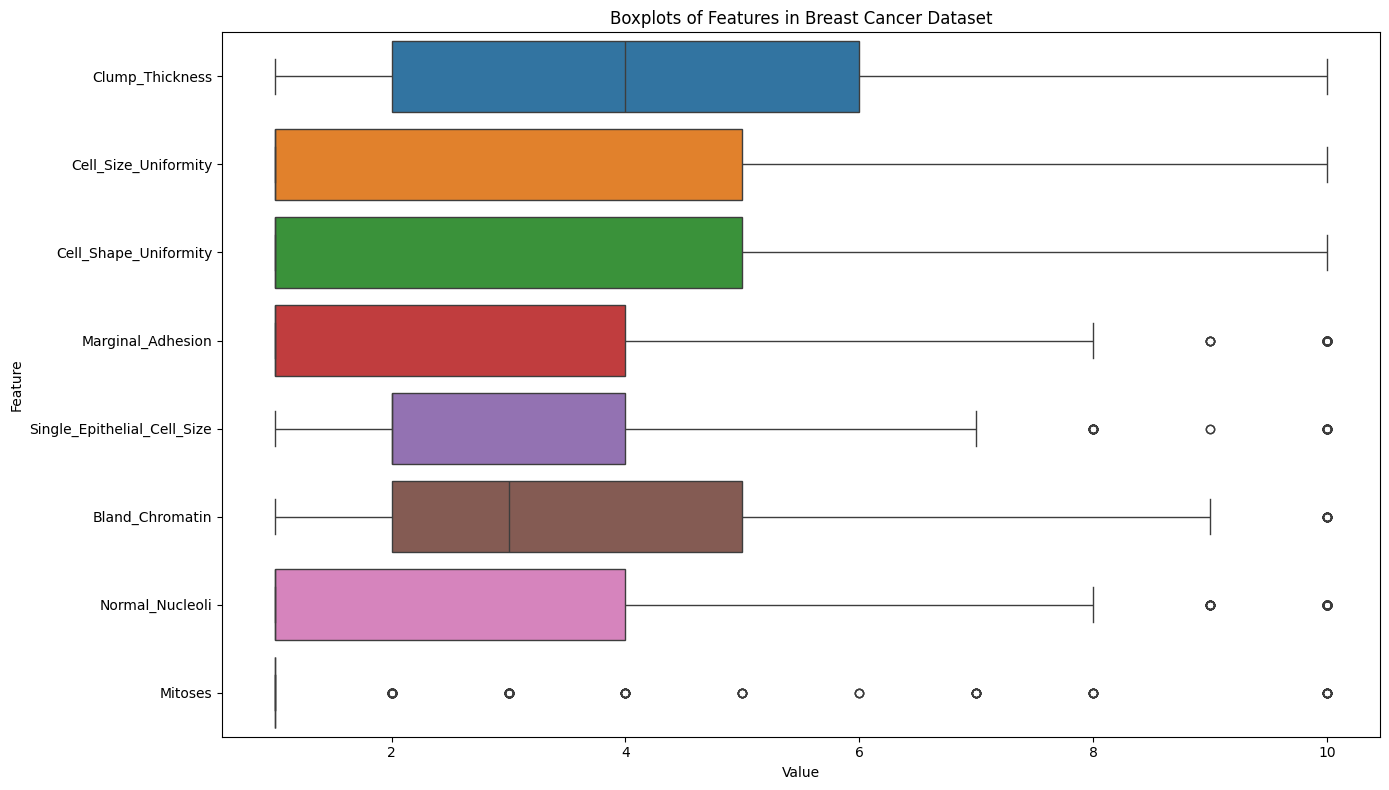

In [ ]:
features = df.drop(['Sample_number', 'Class'], axis=1)

# Plot boxplots for each feature
plt.figure(figsize=(14, 8))
sns.boxplot(data=features, orient="h")
plt.title("Boxplots of Features in Breast Cancer Dataset")
plt.xlabel("Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
Sample_number,0
Clump_Thickness,0
Cell_Size_Uniformity,0
Cell_Shape_Uniformity,0
Marginal_Adhesion,0
Single_Epithelial_Cell_Size,0
Bare_Nuclei,0
Bland_Chromatin,0
Normal_Nucleoli,0
Mitoses,0


In [ ]:
df[df.isin(['?']).any(axis=1)]

,Sample_number,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
23,1057013,8,4,5,1,2,?,7,3,1,4
40,1096800,6,6,6,9,6,?,7,8,1,2
139,1183246,1,1,1,1,1,?,2,1,1,2
145,1184840,1,1,3,1,2,?,2,1,1,2
158,1193683,1,1,2,1,3,?,1,1,1,2
164,1197510,5,1,1,1,2,?,3,1,1,2
235,1241232,3,1,4,1,2,?,3,1,1,2
249,169356,3,1,1,1,2,?,3,1,1,2
275,432809,3,1,3,1,2,?,2,1,1,2
292,563649,8,8,8,1,2,?,6,10,1,4


In [ ]:
df.replace('?', pd.NA, inplace=True)

In [ ]:
df[df.isin(['?']).any(axis=1)]

,Sample_number,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class


# Step 5: Prepare the Data
- Deal with the data as required by the modelling technique
    - **Outliers** (remove or adjust if possible or necessary)
    - **Null** (remove or interpolate if possible or necessary)
    - **Missing Values** (remove or interpolate if possible or necessary)
    - **Coded content** (transform if possible or necessary [str to number or vice-versa])
    - **Feature Engineer** (if useful or necessary)

In [ ]:
df['Class'] = df['Class'].replace({2: 0, 4: 1})

In [ ]:
df = df.apply(pd.to_numeric)

In [ ]:
# Exclude the class column for outlier detection
features = df.drop(['Class'], axis=1)

# Dictionary to store outlier indices for each feature
outlier_indices = {}

# Loop through each feature column
for col in features.columns:
    Q1 = features[col].quantile(0.25)
    Q3 = features[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = features[(features[col] < lower_bound) | (features[col] > upper_bound)].index
    outlier_indices[col] = list(outliers)

# Display the number of outliers per feature
for col, indices in outlier_indices.items():
    print(f"{col}: {len(indices)} outliers")

Sample_number: 23 outliers
Clump_Thickness: 0 outliers
Cell_Size_Uniformity: 0 outliers
Cell_Shape_Uniformity: 0 outliers
Marginal_Adhesion: 60 outliers
Single_Epithelial_Cell_Size: 54 outliers
Bare_Nuclei: 0 outliers
Bland_Chromatin: 20 outliers
Normal_Nucleoli: 77 outliers
Mitoses: 120 outliers


In [ ]:
for col, indices in outlier_indices.items():
    valid_indices = df.index.intersection(indices)
    df = df.drop(index=valid_indices)
df.reset_index(drop=True, inplace=True)

In [ ]:
df.shape

(491, 11)

In [ ]:
X = df.drop('Class', axis=1)
y = df['Class']

# Step 6: Modelling
Refer to the Problem and Main Question.
- What are the input variables (features)?
Clump_Thickness, Cell_Size_Uniformity, Cell_Shape_Uniformity, Marginal_Adhesion, Single_Epithelial_Cell_Size, Bare_Nuclei, Bland_Chromatin, Normal_Nucleoli

Mitoses
- Is there an output variable (label)?

- If there is an output variable:
    - What is it?

    Class, 0 = Benign, 1 = Malignant (after data preparation)

    - What is its type?

    Categorical

- What type of Modelling is it?
    - [x] Supervised
    - [ ] Unsupervised
- What type of Modelling is it?
    - [ ] Regression
    - [x] Classification (binary)
    - [ ] Classification (multi-class)
    - [ ] Clustering

# Step 7: Split the Data

Need to check for **Supervised** modelling:
- Number of known cases or observations
- Define the split in Training/Test or Training/Validation/Test and their proportions
- Check for unbalanced classes and how to keep or avoid it when splitting

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 8: Define and Fit Models

Define the model and its hyper-parameters.

Consider the parameters and hyper-parameters of each model at each (re)run and after checking the efficiency of a model against the training and test datasets.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the base estimator
base_tree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# Define the Bagging ensemble model
bagging_model = BaggingClassifier(
    estimator=base_tree,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    random_state=42
)

bagging_model.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_features=0.8, max_samples=0.8, n_estimators=50,
                  random_state=42)

# Step 9: Verify and Evaluate the Training Model
- Use the **training** data to make predictions
- What metrics are appropriate for the modelling approach used
- For **Supervised** models:
    - Check the **Training Results** with the **Training Predictions** during development
- Analyse, modify the parameters and hyper-parameters and repeat (within reason) until the model does not improve

In [ ]:
# Predict on the training data
y_train_pred = bagging_model.predict(X_train)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))
print("\nTraining Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

Training Accuracy: 1.0

Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       343
           1       1.00      1.00      1.00        49

    accuracy                           1.00       392
   macro avg       1.00      1.00      1.00       392
weighted avg       1.00      1.00      1.00       392


Training Confusion Matrix:
 [[343   0]
 [  0  49]]


# Step 10: Make Predictions and Evaluate the Test Model
**NOTE**: **Do this only after not making any more improvements in the model**.

- Use the **test** data to make predictions
- For **Supervised** models:
    - Check the **Test Results** with the **Test Predictions**

In [ ]:
y_test_pred = bagging_model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
y_test_proba = bagging_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_test_proba)
print("ROC AUC Score:", round(roc_auc, 4))

Test Accuracy: 0.9797979797979798

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99        87
           1       0.86      1.00      0.92        12

    accuracy                           0.98        99
   macro avg       0.93      0.99      0.96        99
weighted avg       0.98      0.98      0.98        99


Confusion Matrix:
 [[85  2]
 [ 0 12]]
ROC AUC Score: 0.9957


# Step 11: Solve the Problem or Answer the Question
The results of an analysis or modelling can be used:
- As part of a product or process, so the model can make predictions when new input data is available
- As part of a report including text and charts to help understand the problem
- As input for further questions

The final model can predict tumor type given new input data



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



